# Custom Encodings

In [1]:
dtypes={'ProductName': 'float32', 'EngineVersion': 'float32', 'AppVersion': 'float32', 'AvSigVersion': 'float32', 'IsBeta': 'float32', 'RtpStateBitfield': 'float32', 'IsSxsPassiveMode': 'float32', 'DefaultBrowsersIdentifier': 'float32', 'AVProductStatesIdentifier': 'float32', 'AVProductsInstalled': 'float32', 'AVProductsEnabled': 'float32', 'HasTpm': 'float32', 'CountryIdentifier': 'float32', 'CityIdentifier': 'float32', 'OrganizationIdentifier': 'float32', 'GeoNameIdentifier': 'float32', 'LocaleEnglishNameIdentifier': 'float32', 'Platform': 'float32', 'Processor': 'float32', 'OsVer': 'float32', 'OsBuild': 'float32', 'OsSuite': 'float32', 'OsPlatformSubRelease': 'float32', 'OsBuildLab': 'float32', 'SkuEdition': 'float32', 'IsProtected': 'float32', 'AutoSampleOptIn': 'float32', 'PuaMode': 'float32', 'SMode': 'float32', 'IeVerIdentifier': 'float32', 'SmartScreen': 'float32', 'Firewall': 'float32', 'UacLuaenable': 'float32', 'Census_MDC2FormFactor': 'float32', 'Census_DeviceFamily': 'float32', 'Census_OEMNameIdentifier': 'float32', 'Census_OEMModelIdentifier': 'float32', 'Census_ProcessorCoreCount': 'float32', 'Census_ProcessorManufacturerIdentifier': 'float32', 'Census_ProcessorModelIdentifier': 'float32', 'Census_ProcessorClass': 'float32', 'Census_PrimaryDiskTotalCapacity': 'float32', 'Census_PrimaryDiskTypeName': 'float32', 'Census_SystemVolumeTotalCapacity': 'float32', 'Census_HasOpticalDiskDrive': 'float32', 'Census_TotalPhysicalRAM': 'float32', 'Census_ChassisTypeName': 'float32', 'Census_InternalPrimaryDiagonalDisplaySizeInInches': 'float32', 'Census_InternalPrimaryDisplayResolutionHorizontal': 'float32', 'Census_InternalPrimaryDisplayResolutionVertical': 'float32', 'Census_PowerPlatformRoleName': 'float32', 'Census_InternalBatteryType': 'float32', 'Census_InternalBatteryNumberOfCharges': 'float32', 'Census_OSVersion': 'float32', 'Census_OSArchitecture': 'float32', 'Census_OSBranch': 'float32', 'Census_OSBuildNumber': 'float32', 'Census_OSBuildRevision': 'float32', 'Census_OSEdition': 'float32', 'Census_OSSkuName': 'float32', 'Census_OSInstallTypeName': 'float32', 'Census_OSInstallLanguageIdentifier': 'float32', 'Census_OSUILocaleIdentifier': 'float32', 'Census_OSWUAutoUpdateOptionsName': 'float32', 'Census_IsPortableOperatingSystem': 'float32', 'Census_GenuineStateName': 'float32', 'Census_ActivationChannel': 'float32', 'Census_IsFlightingInternal': 'float32', 'Census_IsFlightsDisabled': 'float32', 'Census_FlightRing': 'float32', 'Census_ThresholdOptIn': 'float32', 'Census_FirmwareManufacturerIdentifier': 'float32', 'Census_FirmwareVersionIdentifier': 'float32', 'Census_IsSecureBootEnabled': 'float32', 'Census_IsWIMBootEnabled': 'float32', 'Census_IsVirtualDevice': 'float32', 'Census_IsTouchEnabled': 'float32', 'Census_IsPenCapable': 'float32', 'Census_IsAlwaysOnAlwaysConnectedCapable': 'float32', 'Wdft_IsGamer': 'float32', 'Wdft_RegionIdentifier': 'float32', 'HasDetections': 'int8'}
train_dir=r"C:\Users\jithi\OneDrive\Desktop\ML project\Processed Datasets\train_data_scaled_encoded_shrunk.csv"
valid_dir=r'C:\Users\jithi\OneDrive\Desktop\ML project\Processed Datasets\validation_data_scaled_encoded_shrunk.csv'

In [2]:
import pandas as pd
train = pd.read_csv(train_dir, dtype=dtypes)
valid = pd.read_csv(valid_dir, dtype=dtypes)

X_train = train.drop(columns=['HasDetections'])
y_train = train['HasDetections']
X_valid = valid.drop(columns=['HasDetections'])
y_valid = valid['HasDetections']


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import helper_functions
import importlib
import os

importlib.reload(helper_functions)
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_valid.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

#to gpu
if torch.cuda.is_available():
    device = torch.device("cuda")
    X_train_tensor = X_train_tensor.to(device)
    y_train_tensor = y_train_tensor.to(device)
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)


class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),                            
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1) 
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), weight_decay=1e-4,lr=0.0001)  

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
batch_size = 2048
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)  


Without Feature Selection

In [13]:
num_epochs = 100
best_model_weights, train_loss, test_loss, train_accuracy, test_accuracy, lrs = helper_functions.train_and_evaluate_model(model, criterion, optimizer, scheduler, train_loader, test_loader, num_epochs)
torch.save(model.state_dict(), 'simplenn_custom_encodings.pth')

Epoch 1/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:18<00:00, 25.15it/s, acc=62.47%, loss=0.6416]


Epoch 1 Loss: 0.6568, Train Accuracy: 60.64%
Test Loss: 0.6433, Test Accuracy: 62.08%


Epoch 2/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:45<00:00, 21.07it/s, acc=62.26%, loss=0.6314]


Epoch 2 Loss: 0.6402, Train Accuracy: 62.40%
Test Loss: 0.6370, Test Accuracy: 62.67%


Epoch 3/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:49<00:00, 20.52it/s, acc=63.65%, loss=0.6317]


...

Epoch 13 Loss: 0.6234, Train Accuracy: 64.33%
Test Loss: 0.6351, Test Accuracy: 62.11%


Epoch 14/100 - LR: 0.000025: 100%|██████████| 3485/3485 [02:22<00:00, 24.53it/s, acc=64.06%, loss=0.6262]


Epoch 14 Loss: 0.6231, Train Accuracy: 64.35%
Test Loss: 0.6350, Test Accuracy: 62.15%


Epoch 15/100 - LR: 0.000025: 100%|██████████| 3485/3485 [02:56<00:00, 19.77it/s, acc=64.21%, loss=0.6258]


Epoch 15 Loss: 0.6229, Train Accuracy: 64.39%
Test Loss: 0.6345, Test Accuracy: 62.18%
Learning rate changed from 0.000025 to 0.000013
Early stopping triggered at epoch 15. Best model was from epoch 4.


Using PCA for feature selection

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import helper_functions
import importlib
import os

pca_features = [
    "Census_OSBuildNumber",
    "OsBuild",
    "Census_InternalBatteryType",
    "Census_InternalBatteryNumberOfCharges",
    "Census_IsWIMBootEnabled",
    "Census_ThresholdOptIn",
    "OsVer",
    "Platform",
    "Census_ChassisTypeName",
    "Census_MDC2FormFactor",
    "Census_InternalPrimaryDisplayResolutionVertical",
    "Census_OSSkuName",
    "AppVersion",
    "Census_OSEdition",
    "OsSuite",
    "Census_InternalPrimaryDisplayResolutionHorizontal",
    "Census_InternalPrimaryDiagonalDisplaySizeInInches",
    "SkuEdition",
    "OsBuildLab",
    "Census_OSVersion",
    "SmartScreen",
    "Census_TotalPhysicalRAM",
    "Census_OSBranch",
    "Census_PowerPlatformRoleName",
    "ProductName",
    "Census_IsFlightingInternal",
    "HasTpm",
    "Census_ProcessorCoreCount",
    "Census_OSBuildRevision",
    "OsPlatformSubRelease",
    "Census_IsFlightsDisabled",
    "Census_FirmwareManufacturerIdentifier",
    "Census_IsSecureBootEnabled",
    "Firewall",
    "Census_FlightRing",
    "Census_PrimaryDiskTypeName",
    "EngineVersion",
    "IeVerIdentifier",
    "Census_ProcessorModelIdentifier",
    "Census_FirmwareVersionIdentifier",
    "Census_ProcessorClass",
    "AVProductsInstalled",
    "Wdft_IsGamer",
    "Census_OEMNameIdentifier",
    "IsProtected",
    "Processor",
    "Census_OSArchitecture",
    "AVProductStatesIdentifier",
    "SMode",
    "Census_OEMModelIdentifier",
    "Wdft_RegionIdentifier",
    "Census_OSInstallLanguageIdentifier",
    "DefaultBrowsersIdentifier",
    "AVProductsEnabled",
    "Census_GenuineStateName",
    "AvSigVersion",
    "Census_OSWUAutoUpdateOptionsName"
]
# Make sure these exist
assert 'X_train' in locals() and 'y_train' in locals()

# Convert tensors and push to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_pca_tensor = torch.tensor(X_train[pca_features].values, dtype=torch.float32).to(device)
X_valid_pca_tensor = torch.tensor(X_valid[pca_features].values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1).to(device)

# DataLoader
train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
valid_dataset_pca = TensorDataset(X_valid_pca_tensor, y_test_tensor)
train_loader_pca = DataLoader(train_dataset_pca, batch_size=2048, shuffle=True)
test_loader_pca = DataLoader(valid_dataset_pca, batch_size=2048, shuffle=False)

# Model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(X_train_pca_tensor.shape[1], 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()  # Add this only if using BCELoss
        )

    def forward(self, x):
        return self.model(x)



model_pca = MLP().to(device)

criterion = nn.BCEWithLogitsLoss()  # or use nn.BCEWithLogitsLoss and remove sigmoid
optimizer = optim.Adam(model_pca.parameters(), weight_decay=1e-4, lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Train
best_model_weights_pca, train_loss_pca, test_loss_pca, train_accuracy_pca, test_accuracy_pca, lrs_pca = helper_functions.train_and_evaluate_model(
    model_pca, criterion, optimizer, scheduler, train_loader_pca, test_loader_pca, epochs=100
)

torch.save(model_pca.state_dict(), 'simplenn_custom_encodings_pca.pth')



Epoch 1/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:47<00:00, 20.87it/s, acc=50.74%, loss=0.6690]


Epoch 1 Loss: 0.6781, Train Accuracy: 49.98%
Test Loss: 0.6681, Test Accuracy: 49.98%


Epoch 2/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:42<00:00, 21.44it/s, acc=50.03%, loss=0.6667]


Epoch 2 Loss: 0.6672, Train Accuracy: 49.98%
Test Loss: 0.6666, Test Accuracy: 49.98%


Epoch 3/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:32<00:00, 22.89it/s, acc=49.87%, loss=0.6593]


...

Epoch 13 Loss: 0.6619, Train Accuracy: 49.99%
Test Loss: 0.6724, Test Accuracy: 49.98%


Epoch 14/100 - LR: 0.000013: 100%|██████████| 3485/3485 [02:34<00:00, 22.52it/s, acc=51.36%, loss=0.6592]


Epoch 14 Loss: 0.6618, Train Accuracy: 49.99%
Test Loss: 0.6719, Test Accuracy: 49.98%


Epoch 15/100 - LR: 0.000013: 100%|██████████| 3485/3485 [02:33<00:00, 22.63it/s, acc=49.92%, loss=0.6608]


Epoch 15 Loss: 0.6617, Train Accuracy: 50.00%
Test Loss: 0.6728, Test Accuracy: 49.98%
Learning rate changed from 0.000013 to 0.000006
Early stopping triggered at epoch 15. Best model was from epoch 6.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import helper_functions
import importlib
import os

pca_features = [
    "Census_OSBuildNumber",
    "OsBuild",
    "Census_InternalBatteryType",
    "Census_InternalBatteryNumberOfCharges",
    "Census_IsWIMBootEnabled",
    "Census_ThresholdOptIn",
    "OsVer",
    "Platform",
    "Census_ChassisTypeName",
    "Census_MDC2FormFactor",
    "Census_InternalPrimaryDisplayResolutionVertical",
    "Census_OSSkuName",
    "AppVersion",
    "Census_OSEdition",
    "OsSuite",
    "Census_InternalPrimaryDisplayResolutionHorizontal",
    "Census_InternalPrimaryDiagonalDisplaySizeInInches",
    "SkuEdition",
    "OsBuildLab",
    "Census_OSVersion",
    "SmartScreen",
    "Census_TotalPhysicalRAM",
    "Census_OSBranch",
    "Census_PowerPlatformRoleName",
    "ProductName",
    "Census_IsFlightingInternal",
    "HasTpm",
    "Census_ProcessorCoreCount",
    "Census_OSBuildRevision",
    "OsPlatformSubRelease",
    "Census_IsFlightsDisabled",
    "Census_FirmwareManufacturerIdentifier",
    "Census_IsSecureBootEnabled",
    "Firewall",
    "Census_FlightRing",
    "Census_PrimaryDiskTypeName",
    "EngineVersion",
    "IeVerIdentifier",
    "Census_ProcessorModelIdentifier",
    "Census_FirmwareVersionIdentifier",
    "Census_ProcessorClass",
    "AVProductsInstalled",
    "Wdft_IsGamer",
    "Census_OEMNameIdentifier",
    "IsProtected",
    "Processor",
    "Census_OSArchitecture",
    "AVProductStatesIdentifier",
    "SMode",
    "Census_OEMModelIdentifier",
    "Wdft_RegionIdentifier",
    "Census_OSInstallLanguageIdentifier",
    "DefaultBrowsersIdentifier",
    "AVProductsEnabled",
    "Census_GenuineStateName",
    "AvSigVersion",
    "Census_OSWUAutoUpdateOptionsName"
]
# Make sure these exist
assert 'X_train' in locals() and 'y_train' in locals()

# Convert tensors and push to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_pca_tensor = torch.tensor(X_train[pca_features].values, dtype=torch.float32).to(device)
X_valid_pca_tensor = torch.tensor(X_valid[pca_features].values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1).to(device)

# DataLoader
train_dataset_pca = TensorDataset(X_train_pca_tensor, y_train_tensor)
valid_dataset_pca = TensorDataset(X_valid_pca_tensor, y_test_tensor)
train_loader_pca = DataLoader(train_dataset_pca, batch_size=2048, shuffle=True)
test_loader_pca = DataLoader(valid_dataset_pca, batch_size=2048, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 64)  # Input layer to first hidden layer
        self.fc2 = nn.Linear(64, 1)  # First hidden layer to output layer
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
 
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model_pca = MLP().to(device)

criterion = nn.BCEWithLogitsLoss()  # or use nn.BCEWithLogitsLoss and remove sigmoid
optimizer = optim.Adam(model_pca.parameters(), weight_decay=1e-4, lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Train
best_model_weights_pca, train_loss_pca, test_loss_pca, train_accuracy_pca, test_accuracy_pca, lrs_pca = helper_functions.train_and_evaluate_model(
    model_pca, criterion, optimizer, scheduler, train_loader_pca, test_loader_pca, epochs=100
)

torch.save(model_pca.state_dict(), 'simplenn_custom_encodings_pca.pth')



Using LDA for feature selection

In [19]:
import torch
torch.cuda.empty_cache()


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import helper_functions
import os

# Use CUDA blocking for better traceback during errors

lda_features = [
    'Census_OSEdition', 'Census_OSSkuName', 'AVProductsInstalled', 'EngineVersion', 'SmartScreen',
    'AVProductStatesIdentifier', 'Census_ThresholdOptIn', 'IsProtected', 'Census_OSInstallTypeName',
    'Census_IsVirtualDevice', 'Census_InternalPrimaryDisplayResolutionVertical', 'OsSuite',
    'Census_InternalPrimaryDisplayResolutionHorizontal', 'Processor',
    'Census_IsAlwaysOnAlwaysConnectedCapable', 'Wdft_IsGamer', 'Census_OSVersion',
    'Census_OSUILocaleIdentifier', 'Census_InternalBatteryNumberOfCharges', 'Census_IsTouchEnabled',
    'Census_OSBuildNumber', 'HasTpm', 'SMode', 'Census_MDC2FormFactor',
    'Census_OSInstallLanguageIdentifier', 'Census_DeviceFamily', 'Census_HasOpticalDiskDrive',
    'Census_TotalPhysicalRAM', 'Census_InternalBatteryType', 'Census_PrimaryDiskTypeName',
    'LocaleEnglishNameIdentifier', 'ProductName', 'Census_ProcessorCoreCount', 'Wdft_RegionIdentifier',
    'DefaultBrowsersIdentifier', 'Census_IsSecureBootEnabled', 'Census_GenuineStateName',
    'RtpStateBitfield', 'OsBuild', 'SkuEdition', 'OsPlatformSubRelease', 'Census_IsFlightingInternal',
    'Census_FlightRing', 'OsVer', 'Census_ProcessorModelIdentifier', 'Census_ActivationChannel',
    'IeVerIdentifier', 'Census_OSBuildRevision', 'AvSigVersion', 'AppVersion',
    'Census_OSWUAutoUpdateOptionsName', 'Census_OEMNameIdentifier', 'Census_OSArchitecture',
    'Census_ChassisTypeName', 'Census_PowerPlatformRoleName', 'PuaMode', 'Census_OEMModelIdentifier',
    'Census_ProcessorClass', 'Census_ProcessorManufacturerIdentifier', 'Census_IsFlightsDisabled',
    'Census_OSBranch', 'AVProductsEnabled', 'Census_SystemVolumeTotalCapacity', 'CityIdentifier',
    'Census_IsPortableOperatingSystem', 'IsSxsPassiveMode', 'Census_FirmwareManufacturerIdentifier',
    'OrganizationIdentifier', 'Census_InternalPrimaryDiagonalDisplaySizeInInches', 'AutoSampleOptIn',
    'OsBuildLab', 'Census_FirmwareVersionIdentifier', 'CountryIdentifier', 'UacLuaenable', 'IsBeta',
    'Firewall', 'Census_IsPenCapable', 'Census_PrimaryDiskTotalCapacity', 'Platform',
    'Census_IsWIMBootEnabled', 'GeoNameIdentifier'
]

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert tensors
X_train_lda_tensor = torch.tensor(X_train[lda_features].values, dtype=torch.float32).to(device)
X_valid_lda_tensor = torch.tensor(X_valid[lda_features].values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1).to(device)

# Datasets & Loaders
train_dataset_lda = TensorDataset(X_train_lda_tensor, y_train_tensor)
valid_dataset_lda = TensorDataset(X_valid_lda_tensor, y_test_tensor)

batch_size = 2048
train_loader_lda = DataLoader(train_dataset_lda, batch_size=batch_size, shuffle=True)
test_loader_lda = DataLoader(valid_dataset_lda, batch_size=batch_size, shuffle=False)

# MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(X_train_lda_tensor.shape[1], 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Do not add sigmoid if using BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.model(x)

# Training setup
model_lda = MLP().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_lda.parameters(), weight_decay=1e-4, lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Train & evaluate
num_epochs = 100
best_model_weights_lda, train_loss_lda, test_loss_lda, train_accuracy_lda, test_accuracy_lda, lrs_lda = helper_functions.train_and_evaluate_model(
    model_lda, criterion, optimizer, scheduler, train_loader_lda, test_loader_lda, num_epochs
)

# Save model
torch.save(model_lda.state_dict(), 'simplenn_custom_encodings_lda.pth')


Epoch 1/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:17<00:00, 25.41it/s, acc=61.44%, loss=0.6501]


Epoch 1 Loss: 0.6605, Train Accuracy: 60.11%
Test Loss: 0.6449, Test Accuracy: 61.83%


Epoch 2/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:15<00:00, 25.67it/s, acc=64.11%, loss=0.6319]


Epoch 2 Loss: 0.6412, Train Accuracy: 62.27%
Test Loss: 0.6379, Test Accuracy: 62.55%


Epoch 3/100 - LR: 0.000100: 100%|██████████| 3485/3485 [02:15<00:00, 25.66it/s, acc=61.29%, loss=0.6436]


...

Epoch 12 Loss: 0.6240, Train Accuracy: 64.24%
Test Loss: 0.6356, Test Accuracy: 62.04%


Epoch 13/100 - LR: 0.000025: 100%|██████████| 3485/3485 [02:16<00:00, 25.59it/s, acc=65.03%, loss=0.6256]


Epoch 13 Loss: 0.6238, Train Accuracy: 64.28%
Test Loss: 0.6359, Test Accuracy: 62.01%


Epoch 14/100 - LR: 0.000025: 100%|██████████| 3485/3485 [02:14<00:00, 25.85it/s, acc=65.64%, loss=0.6207]


Epoch 14 Loss: 0.6235, Train Accuracy: 64.30%
Test Loss: 0.6355, Test Accuracy: 62.04%
Learning rate changed from 0.000025 to 0.000013
Early stopping triggered at epoch 14. Best model was from epoch 4.


In [8]:
#print (train_loss, test_loss, train_accuracy, test_accuracy, lrs)
# print(train_loss, test_loss, train_accuracy, test_accuracy, lrs)
print (train_loss_pca, test_loss_pca, train_accuracy_pca, test_accuracy_pca, lrs_pca)
print (train_loss_lda, test_loss_lda, train_accuracy_lda, test_accuracy_lda, lrs_lda)

[0.6781015894847415, 0.6672113574218203, 0.6652801844789786, 0.664196052270777, 0.6635671329464085, 0.6631654388935357, 0.6627556509745857, 0.662549143268525, 0.6624040359746093, 0.6621542451713486, 0.662083598565166, 0.6619448768015058, 0.6618598198959099, 0.6618050929121513, 0.6617284793251728] [0.6680534428686177, 0.6665786795933312, 0.6656387594588306, 0.6659142686686385, 0.6663651842316356, 0.6673928773321143, 0.6679413810098936, 0.6689181996321459, 0.6694454255454038, 0.6701364805665585, 0.6706523450962995, 0.6716678634012511, 0.6723777846595563, 0.6719472080195715, 0.6727840811561007] [0.4997938262774469, 0.4997992906166787, 0.49986654402260833, 0.4999891413771676, 0.5000059547286501, 0.5000259906391665, 0.49999642716281, 0.4999527124489557, 0.49996770435402754, 0.49994598710836274, 0.49994514644078863, 0.4999522921151687, 0.49994444588447684, 0.49994808877729807, 0.4999557948967275] [0.4997929156412862, 0.49979403653091387, 0.49979403653091387, 0.49979515742054154, 0.4997957178

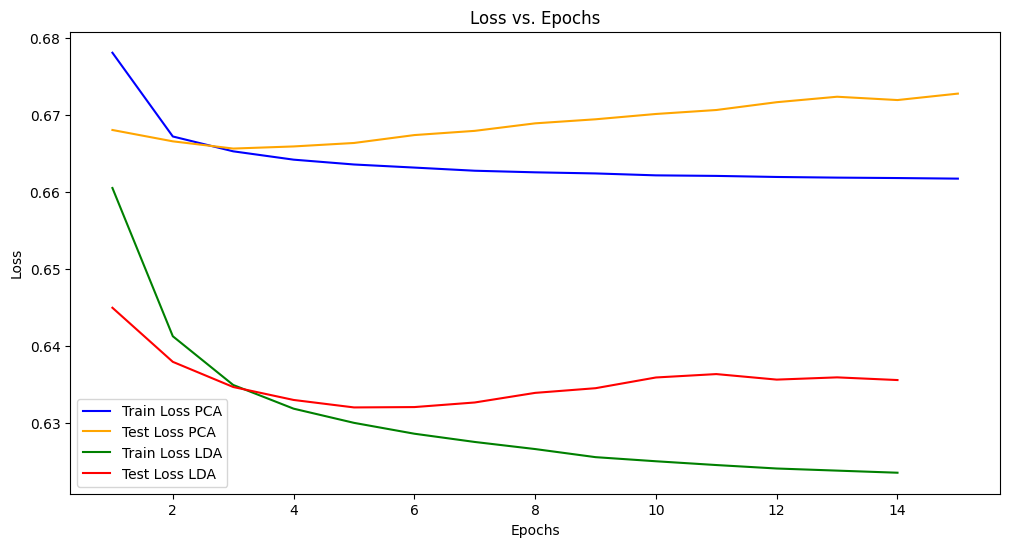

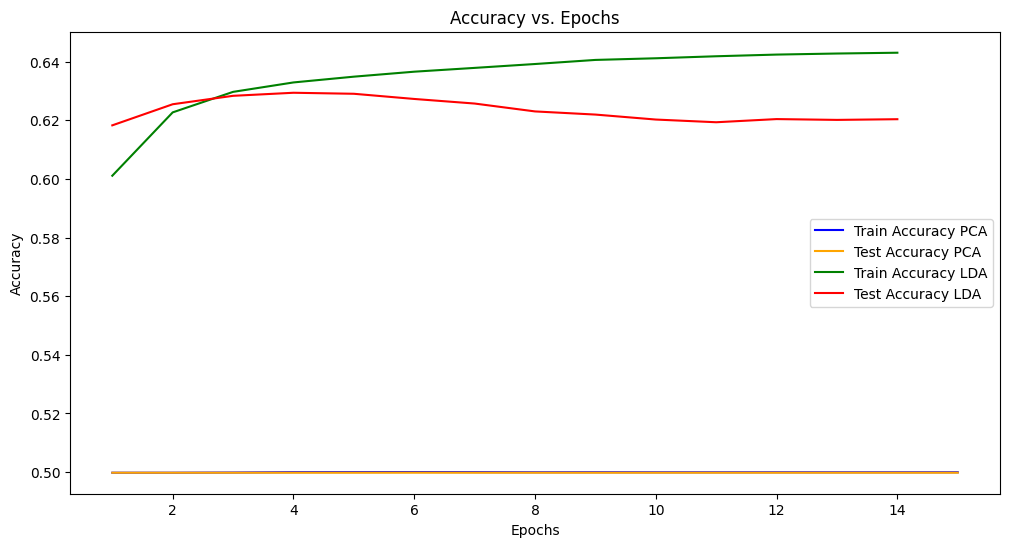

In [9]:
import matplotlib.pyplot as plt
import numpy as np


# Plotting function
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, len(train_loss_pca) + 1), train_loss_pca, label='Train Loss PCA', color='blue')
plt.plot(np.arange(1, len(test_loss_pca) + 1), test_loss_pca, label='Test Loss PCA', color='orange')
plt.plot(np.arange(1, len(train_loss_lda) + 1), train_loss_lda, label='Train Loss LDA', color='green')
plt.plot(np.arange(1, len(test_loss_lda) + 1), test_loss_lda, label='Test Loss LDA', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.show()

# Plotting function for accuracy
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, len(train_accuracy_pca) + 1), train_accuracy_pca, label='Train Accuracy PCA', color='blue')   
plt.plot(np.arange(1, len(test_accuracy_pca) + 1), test_accuracy_pca, label='Test Accuracy PCA', color='orange')
plt.plot(np.arange(1, len(train_accuracy_lda) + 1), train_accuracy_lda, label='Train Accuracy LDA', color='green')
plt.plot(np.arange(1, len(test_accuracy_lda) + 1), test_accuracy_lda, label='Test Accuracy LDA', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.show()

In [ ]:
# from sklearn.svm import LinearSVC  # More efficient for linear kernels
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import pandas as pd

# # Use LinearSVC which is optimized for linear kernels
# linear_svc = LinearSVC(
#     C=1.0,                  # Regularization parameter
#     penalty='l2',           # Default is l2 penalty
#     loss='squared_hinge',   # Default loss for L2 penalty
#     dual=False,              # Dual formulation is faster when n_samples > n_features
#     random_state=42,
#     max_iter=1000           # Increase if convergence issues occur
# )

# # Train the model
# print("Training LinearSVC...")
# linear_svc.fit(X_train_scaled, y_train)

# # Make predictions
# train_pred = linear_svc.predict(X_train_scaled)
# valid_pred = linear_svc.predict(X_test_scaled)

# # Calculate metrics
# train_accuracy = accuracy_score(y_train, train_pred)
# valid_accuracy = accuracy_score(y_valid, valid_pred)

# print(f"\nTraining Accuracy: {train_accuracy:.4f}")
# print(f"Validation Accuracy: {valid_accuracy:.4f}")

# print("\nClassification Report (Validation Set):")
# print(classification_report(y_valid, valid_pred))

Training LinearSVC...

Training Accuracy: 0.5988
Validation Accuracy: 0.5909

Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.61      0.52      0.56    892519
           1       0.58      0.66      0.62    891778

    accuracy                           0.59   1784297
   macro avg       0.59      0.59      0.59   1784297
weighted avg       0.59      0.59      0.59   1784297



In [ ]:
# from sklearn.linear_model import LogisticRegression
# logreg = LogisticRegression()
# logreg.fit(X_train, y_train)
# labels = logreg.predict(X_train)
# print(accuracy_score(y_train, labels))
# test_labels = logreg.predict(X_valid)
# print(accuracy_score(y_test, test_labels))

0.5989099343788903
0.590950945946779


In [ ]:
# #perceptron
# from sklearn.linear_model import Perceptron
# from sklearn.metrics import accuracy_score
# perceptron = Perceptron()
# perceptron.fit(X_train, y_train)
# labels = perceptron.predict(X_train)
# print(accuracy_score(y_train, labels))
# test_labels = perceptron.predict(X_valid)
# print(accuracy_score(y_test, test_labels))

0.5602409073044905
0.552740378983992


In [ ]:
# from sklearn.svm import LinearSVC
# from sklearn.kernel_approximation import RBFSampler
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score

# rbf_feature = RBFSampler(gamma=0.1, n_components=200, random_state=42)  # Adjust `n_components`

# linear_svc = LinearSVC(dual=False, max_iter=5000)

# svm_pipeline = Pipeline([
#     ('rbf_feature', rbf_feature),
#     ('svm', linear_svc)
# ])

# svm_pipeline.fit(X_train, y_train)

# train_preds = svm_pipeline.predict(X_train)
# test_preds = svm_pipeline.predict(X_valid)

# print("Train Accuracy:", accuracy_score(y_train, train_preds))
# print("Test Accuracy:", accuracy_score(y_test, test_preds))


In [ ]:
svm_train= 0.5988
svm_vali = 0.5909
lr_train = 0.5989099343788903
lr_vali = 0.590950945946779
perceptron_train = 0.5602409073044905
perceptron_vali = 0.552740378983992
simple_nn_train = 0.6344
simple_nn_vali = 0.6261
simple_nn_pca_train = 0.6308
simple_nn_pca_vali = 0.6206
simple_nn_lda_train = 0.6341
simple_nn_lda_vali = 0.6257
kernel_svm_train = 0.5412003471957081
kernel_svm_vali = 0.5413975363966873
xgboost_train = 0.6640019839754749
xgboost_vali = 0.6612251211541577
dnn_train = 0.6619
dnn_vali = 0.6578


# lda_submission scores
lda_private_score = 0.50846
lda_public_score = 0.51887

# pca_submission scores
pca_private_score = 0.51341
pca_public_score = 0.49596

# Simple NN entire scores
nn_private_score = 0.49087
nn_public_score = 0.50434

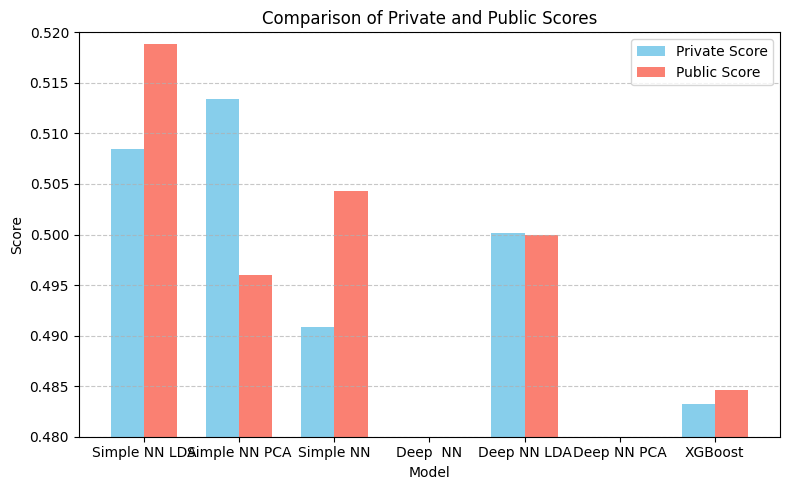

In [ ]:
# import matplotlib.pyplot as plt

# # Labels and scores
# models = ['Simple NN LDA', 'Simple NN PCA', 'Simple NN', 'Deep  NN', 'Deep NN LDA' , 'Deep NN PCA', 'XGBoost']
# private_scores = [0.50846, 0.51341, 0.49087,0,0.50012,0,0.48328]
# public_scores = [0.51887, 0.49596, 0.50434,0,0.49996,0,0.48466]

# x = range(len(models))
# bar_width = 0.35

# # Plotting
# plt.figure(figsize=(8, 5))
# plt.bar(x, private_scores, width=bar_width, label='Private Score', color='skyblue')
# plt.bar([i + bar_width for i in x], public_scores, width=bar_width, label='Public Score', color='salmon')

# plt.xlabel('Model')
# plt.ylabel('Score')
# plt.title('Comparison of Private and Public Scores')
# plt.xticks([i + bar_width / 2 for i in x], models)
# plt.ylim(0.48, 0.52)  # Zoom in to show score differences more clearly
# plt.legend()
# plt.tight_layout()
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()


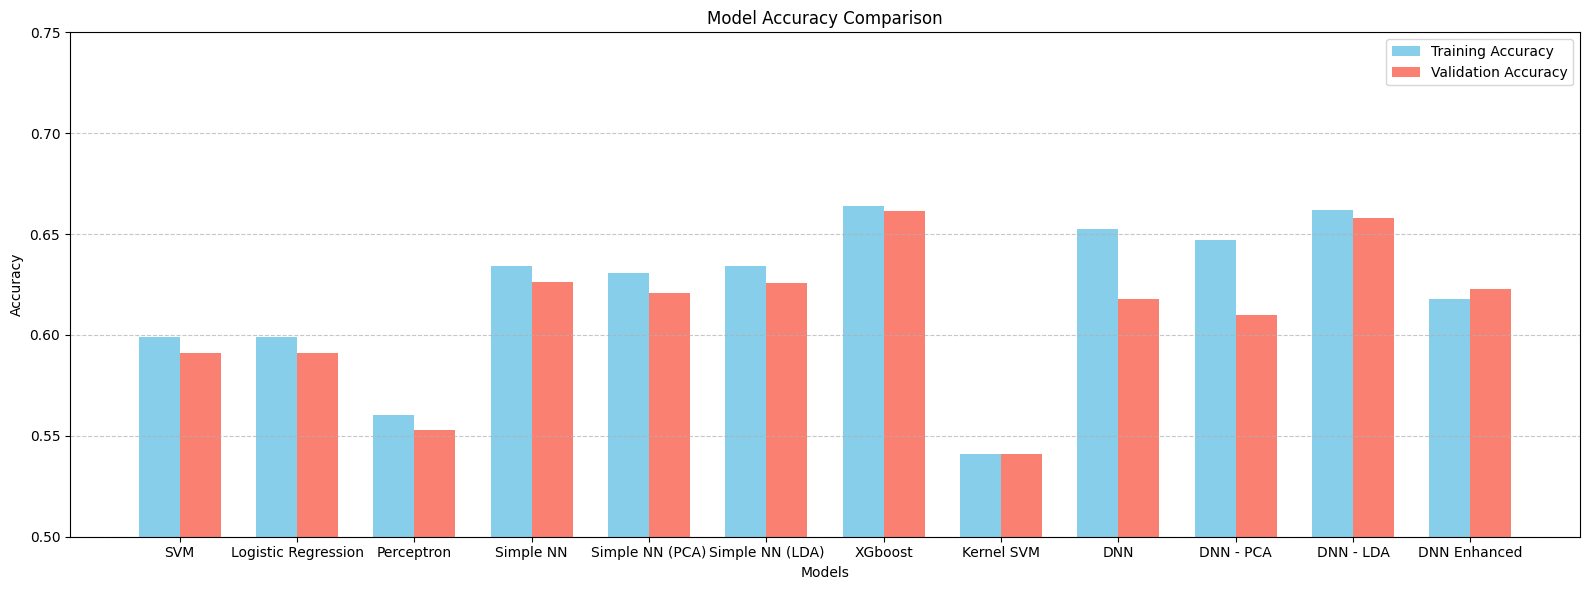

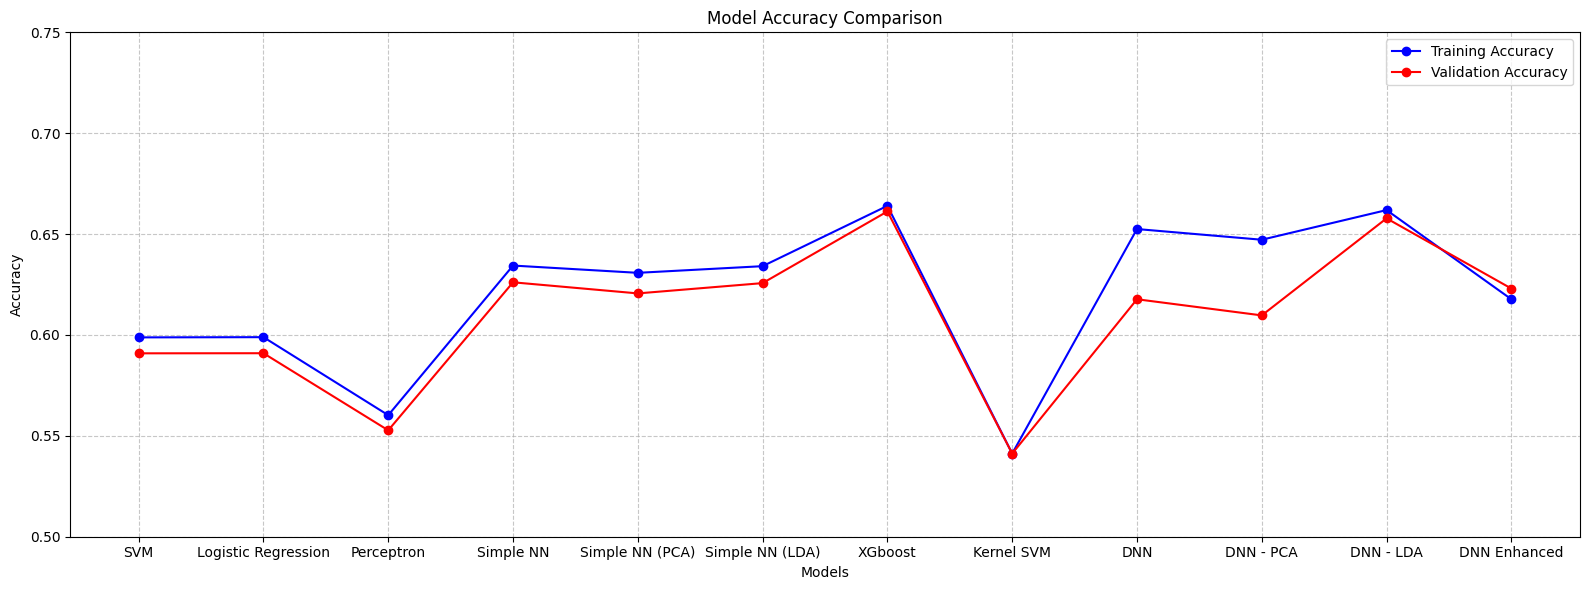

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Model names
# models = ['SVM', 'Logistic Regression', 'Perceptron', 'Simple NN', 'Simple NN (PCA)', 'Simple NN (LDA)','XGboost','Kernel SVM','DNN','DNN - PCA','DNN - LDA','DNN Enhanced']

# # Accuracies (as provided)
# train_accuracies = [0.5988, 0.5989099343788903, 0.5602409073044905, 0.6344, 0.6308, 0.6341,0.6640019839754749,0.5412003471957081,0.6525,0.6472,0.6619,0.6177]
# validation_accuracies = [0.5909, 0.590950945946779, 0.552740378983992, 0.6261, 0.6206, 0.6257,0.6612251211541577,0.5412003471957081,0.6177,0.6097,0.6578,0.6230]

# # Set positions and width for the bars
# x = np.arange(len(models))
# width = 0.35

# plt.figure(figsize=(16, 6))
# plt.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
# plt.bar(x + width/2, validation_accuracies, width, label='Validation Accuracy', color='salmon')

# plt.xlabel('Models')
# plt.ylabel('Accuracy')
# plt.title('Model Accuracy Comparison')
# plt.xticks(x, models)
# plt.ylim(0.50, 0.75)
# plt.legend()
# plt.tight_layout()  # make sure labels don't get cut off
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

# x = np.arange(len(models))
# width = 0.35

# plt.figure(figsize=(16, 6))
# plt.plot(models, train_accuracies, marker='o', label='Training Accuracy', color='blue')
# plt.plot(models, validation_accuracies, marker='o', label='Validation Accuracy', color='red')

# plt.xlabel("Models")
# plt.ylabel("Accuracy")
# plt.title("Model Accuracy Comparison")
# plt.ylim(0.50, 0.75)
# plt.legend()
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()  # make sure labels don't get cut off
# plt.show()

# With Kaggles Encodings

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
train_dtypes=test_dtypes=dtypes = {
    'ProductName':                                                  'float32',
    'IsBeta':                                                       'float32',
    'RtpStateBitfield':                                             'float32',
    'IsSxsPassiveMode':                                             'float32',
    'DefaultBrowsersIdentifier':                                    'float32',
    'AVProductStatesIdentifier':                                    'float32',
    'AVProductsInstalled':                                          'float32',
    'AVProductsEnabled':                                            'float32',
    'HasTpm':                                                       'float32',
    'CountryIdentifier':                                            'float32',
    'CityIdentifier':                                               'float32',
    'OrganizationIdentifier':                                       'float32',
    'GeoNameIdentifier':                                            'float32',
    'LocaleEnglishNameIdentifier':                                  'float32',
    'Platform':                                                     'float32',
    'Processor':                                                    'float32',
    'OsVer':                                                        'float32',
    'OsBuild':                                                      'float32',
    'OsSuite':                                                      'float32',
    'OsPlatformSubRelease':                                         'float32',
    'OsBuildLab':                                                   'float32',
    'SkuEdition':                                                   'float32',
    'IsProtected':                                                  'float32',
    'AutoSampleOptIn':                                              'float32',
    'PuaMode':                                                      'float32',
    'SMode':                                                        'float32',
    'IeVerIdentifier':                                              'float32',
    'SmartScreen':                                                  'float32',
    'Firewall':                                                     'float32',
    'UacLuaenable':                                                 'float32',
    'Census_MDC2FormFactor':                                        'float32',
    'Census_DeviceFamily':                                          'float32',
    'Census_OEMNameIdentifier':                                     'float32',
    'Census_OEMModelIdentifier':                                    'float32',
    'Census_ProcessorCoreCount':                                    'float32',
    'Census_ProcessorManufacturerIdentifier':                       'float32',
    'Census_ProcessorModelIdentifier':                              'float32',
    'Census_ProcessorClass':                                        'float32',
    'Census_PrimaryDiskTotalCapacity':                              'float32',
    'Census_PrimaryDiskTypeName':                                   'float32',
    'Census_SystemVolumeTotalCapacity':                             'float32',
    'Census_HasOpticalDiskDrive':                                   'float32',
    'Census_TotalPhysicalRAM':                                      'float32',
    'Census_ChassisTypeName':                                       'float32',
    'Census_InternalPrimaryDiagonalDisplaySizeInInches':            'float32',
    'Census_InternalPrimaryDisplayResolutionHorizontal':            'float32',
    'Census_InternalPrimaryDisplayResolutionVertical':              'float32',
    'Census_PowerPlatformRoleName':                                 'float32',
    'Census_InternalBatteryType':                                   'float32',
    'Census_InternalBatteryNumberOfCharges':                        'float32',
    'Census_OSArchitecture':                                        'float32',
    'Census_OSBranch':                                              'float32',
    'Census_OSBuildNumber':                                         'float32',
    'Census_OSBuildRevision':                                       'float32',
    'Census_OSEdition':                                             'float32',
    'Census_OSSkuName':                                             'float32',
    'Census_OSInstallTypeName':                                     'float32',
    'Census_OSInstallLanguageIdentifier':                           'float32',
    'Census_OSUILocaleIdentifier':                                  'float32',
    'Census_OSWUAutoUpdateOptionsName':                             'float32',
    'Census_IsPortableOperatingSystem':                             'float32',
    'Census_GenuineStateName':                                      'float32',
    'Census_ActivationChannel':                                     'float32',
    'Census_IsFlightingInternal':                                   'float32',
    'Census_IsFlightsDisabled':                                     'float32',
    'Census_FlightRing':                                            'float32',
    'Census_ThresholdOptIn':                                        'float32',
    'Census_FirmwareManufacturerIdentifier':                        'float32',
    'Census_FirmwareVersionIdentifier':                             'float32',
    'Census_IsSecureBootEnabled':                                   'float32',
    'Census_IsWIMBootEnabled':                                      'float32',
    'Census_IsVirtualDevice':                                       'float32',
    'Census_IsTouchEnabled':                                        'float32',
    'Census_IsPenCapable':                                          'float32',
    'Census_IsAlwaysOnAlwaysConnectedCapable':                      'float32',
    'Wdft_IsGamer':                                                 'float32',
    'Wdft_RegionIdentifier':                                        'float32',
    'EngineVersion_1':                                              'int8',
    'EngineVersion_2':                                              'int8',
    'EngineVersion_3':                                              'float32',
    'EngineVersion_4':                                              'float32',
    'AppVersion_1':                                                 'int8',
    'AppVersion_2':                                                 'float32',
    'AppVersion_3':                                                 'float32',
    'AppVersion_4':                                                 'float32',
    'AvSigVersion_1':                                               'float32',
    'AvSigVersion_2':                                               'float32',
    'AvSigVersion_3':                                               'float32',
    'AvSigVersion_4':                                               'int8',
    'Census_OSVersion_1':                                           'float32',
    'Census_OSVersion_2':                                           'float32',
    'Census_OSVersion_3':                                           'float32',
    'Census_OSVersion_4':                                           'float32',
    'HasDetections':                                                'int8',
}
train_data = pd.read_csv(r'C:\Users\jithi\OneDrive\Desktop\ML project\Processed Datasets\train_data_kaggle_processed.csv',dtype=train_dtypes)
test_data = pd.read_csv(r'C:\Users\jithi\OneDrive\Desktop\ML project\Processed Datasets\validation_data_kaggle_processed.csv',dtype=test_dtypes)

X_train = train_data.drop('HasDetections', axis=1)
y_train = train_data['HasDetections']
X_valid = test_data.drop('HasDetections', axis=1)
y_valid = test_data['HasDetections']

del train_data, test_data
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_valid.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

# class MLP(nn.Module):
#     def __init__(self):
#         super(MLP, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(X_train_tensor.shape[1], 64),
#             nn.BatchNorm1d(64),       # helps stabilize training
#             nn.ReLU(),
#             nn.Dropout(0.3),          # regularization
            
#             nn.Linear(64, 32),        # extra layer for more representation power
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(0.3),
            
#             nn.Linear(32, 1)          # output logits
#         )

#     def forward(self, x):
#         return self.model(x)

 

In [ ]:
import helper_functions
import importlib
importlib.reload(helper_functions)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 64)  # Input layer to first hidden layer
        self.fc2 = nn.Linear(64, 1)  # First hidden layer to output layer
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
 
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MLP()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), weight_decay=1e-4,lr=0.001) 
model.to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
batch_size = 4096
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)  

num_epochs = 100
best_model_weights, train_loss, test_loss, train_accuracy, test_accuracy, lrs = helper_functions.train_and_evaluate_model(model, criterion, optimizer, scheduler, train_loader, test_loader, num_epochs)

torch.save(best_model_weights, 'simplenn_kaggle_encodings.pth')


Epoch 1/100 - LR: 0.001000:   0%|          | 0/1743 [00:00<?, ?it/s]

Epoch 1/100 - LR: 0.001000: 100%|██████████| 1743/1743 [02:25<00:00, 12.02it/s, acc=65.52%, loss=0.6204]


Epoch 1 Loss: 0.6415, Train Accuracy: 62.48%
Test Loss: 0.6322, Test Accuracy: 63.40%


Epoch 2/100 - LR: 0.001000: 100%|██████████| 1743/1743 [03:06<00:00,  9.35it/s, acc=63.31%, loss=0.6405]


Epoch 2 Loss: 0.6305, Train Accuracy: 63.59%
Test Loss: 0.6301, Test Accuracy: 63.63%


...

Epoch 39 Loss: 0.6201, Train Accuracy: 64.72%
Test Loss: 0.6210, Test Accuracy: 64.61%


Epoch 40/100 - LR: 0.000125: 100%|██████████| 1743/1743 [02:55<00:00,  9.95it/s, acc=63.01%, loss=0.6295]


Epoch 40 Loss: 0.6201, Train Accuracy: 64.71%
Test Loss: 0.6209, Test Accuracy: 64.61%


Epoch 41/100 - LR: 0.000125: 100%|██████████| 1743/1743 [02:26<00:00, 11.90it/s, acc=66.03%, loss=0.6098]


Epoch 41 Loss: 0.6201, Train Accuracy: 64.72%


In [ ]:
#plot results

import matplotlib.pyplot as plt

plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(test_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

NameError: name 'train_loss' is not defined